# Prediksi & Backtest Saham Sektor Kesehatan (Periode 7 Hari)

Notebook ini melakukan:
1. **Download data** harga saham untuk 8 ticker sektor kesehatan (IDX).
2. **Exploratory Data Analysis (EDA)** untuk memahami karakteristik data sebelum modeling.
3. **Feature Engineering** (RSI, TEMA, Bollinger Band Width, Volume Relatif, Momentum).
4. **Labeling** sinyal Buy/Hold/Sell berdasarkan return 7 hari ke depan.
5. **Modeling** menggunakan Random Forest per ticker (parameter sudah di-tuning sebelumnya).
6. **Backtesting** strategi menggunakan library `backtesting`.
7. **Evaluasi** menggunakan confusion matrix & ringkasan performa.

Setiap tahapan dipisah menjadi cell tersendiri agar mudah dijalankan dan dimodifikasi satu per satu di Google Colab.


## 1. Instalasi Library

Jalankan cell ini terlebih dahulu jika library belum tersedia di environment Colab (`pandas_ta` dan `backtesting` biasanya belum ter-install secara default).


In [1]:
# !pip install -q pandas_ta backtesting


## 2. Import Library

Mengimpor seluruh library yang dibutuhkan:
- `yfinance` untuk download data harga saham.
- `pandas_ta` untuk indikator teknikal (RSI, TEMA, Bollinger Bands).
- `scikit-learn` untuk model Random Forest & evaluasi.
- `backtesting` untuk simulasi strategi trading.
- `matplotlib` & `seaborn` untuk visualisasi (termasuk EDA).


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from backtesting import Backtest, Strategy

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

## 3. Konfigurasi

Berisi daftar ticker yang akan dianalisis, parameter Random Forest hasil tuning per ticker,
daftar fitur yang dipakai model, serta parameter labeling (`lookup_periode` dan `threshold`).


In [3]:
tickers_list = [
    "BMHS.JK",
    "DGNS.JK",
    "HEAL.JK",
    "MIKA.JK",
    "PRDA.JK",
    "PRIM.JK",
    "SAME.JK",
    "SILO.JK"
]

rf_params_map = {
    "PRIM.JK": {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 400},
    "BMHS.JK": {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50},
    "PRDA.JK": {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50},
    "SAME.JK": {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 200},
    "HEAL.JK": {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200},
    "SILO.JK": {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50},
    "DGNS.JK": {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 100},
    "MIKA.JK": {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 400},
}


features = [
    'rsi',
    'tema_20_rel',
    'bb_width',
    'volume_rel',
    'momentum_5',
]

lookup_periode = 7
threshold = 0.025

results = []
testing_cms = []
backtesting_cms = []

labels = ["Sell", "Hold", "Buy"]


## 4. Download Data Harga Saham

Mengunduh data harian (OHLCV) untuk semua ticker dari Yahoo Finance, periode 2020-01-01 s/d 2025-12-31.
Data disimpan dalam dictionary `raw_data` agar bisa dipakai ulang, baik untuk EDA maupun tahap modeling,
tanpa perlu download berkali-kali.


In [4]:
raw_data = {}

for ticker in tickers_list:
    print(f"Downloading {ticker} ...")

    data = yf.download(
        ticker,
        start='2020-01-01',
        end='2025-12-31',
        auto_adjust=False,
        multi_level_index=False,
        interval='1d'
    )

    if data.empty:
        print(f"Data kosong untuk {ticker}, skip...")
        continue

    raw_data[ticker] = data

print(f"\nTotal ticker berhasil di-download: {len(raw_data)} dari {len(tickers_list)}")


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed


Total ticker berhasil di-download: 8 dari 8


## 5. Exploratory Data Analysis (EDA)

Sebelum masuk ke feature engineering dan modeling, kita eksplorasi dulu data mentahnya:
jumlah baris, rentang tanggal, missing value, statistik deskriptif, tren harga, distribusi return,
serta korelasi antar saham. Tujuannya untuk memastikan data bersih dan memahami karakteristik tiap saham.


### 5.1 Ringkasan Umum Data

Menampilkan jumlah baris, rentang tanggal, jumlah missing value, dan harga close terakhir untuk tiap ticker.


In [5]:
eda_summary = []

for ticker, df in raw_data.items():
    eda_summary.append({
        "Ticker": ticker,
        "Jumlah Baris": len(df),
        "Tanggal Awal": df.index.min().date(),
        "Tanggal Akhir": df.index.max().date(),
        "Missing Values": int(df.isna().sum().sum()),
        "Harga Close Terakhir": df['Close'].iloc[-1]
    })

eda_summary_df = pd.DataFrame(eda_summary)
eda_summary_df


,Ticker,Jumlah Baris,Tanggal Awal,Tanggal Akhir,Missing Values,Harga Close Terakhir
0,BMHS.JK,1082,2021-07-06,2025-12-30,0,190.0
1,DGNS.JK,1196,2021-01-15,2025-12-30,0,184.0
2,HEAL.JK,1447,2020-01-02,2025-12-30,0,1375.0
3,MIKA.JK,1447,2020-01-02,2025-12-30,0,2380.0
4,PRDA.JK,1447,2020-01-02,2025-12-30,0,2300.0
5,PRIM.JK,1447,2020-01-02,2025-12-30,0,83.0
6,SAME.JK,1447,2020-01-02,2025-12-30,0,362.0
7,SILO.JK,1447,2020-01-02,2025-12-30,0,2740.0


### 5.2 Statistik Deskriptif per Ticker

Melihat sebaran nilai Open, High, Low, Close, dan Volume (mean, std, min, max, kuartil) untuk tiap saham.


In [6]:
for ticker, df in raw_data.items():
    print(f"\n=== Statistik Deskriptif: {ticker} ===")
    print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())



=== Statistik Deskriptif: BMHS.JK ===
              Open         High          Low        Close        Volume
count  1082.000000  1082.000000  1082.000000  1082.000000  1.082000e+03
mean    446.178373   454.849353   434.058226   443.789279  1.124015e+07
std     244.809225   250.531742   238.243129   244.577315  4.131512e+07
min     149.000000   151.000000   143.000000   147.000000  0.000000e+00
25%     278.500000   288.000000   266.500000   276.000000  5.650000e+05
50%     376.000000   380.000000   368.000000   374.000000  1.899500e+06
75%     590.000000   595.000000   575.000000   590.000000  9.284475e+06
max    1155.000000  1200.000000  1090.000000  1145.000000  9.859078e+08

=== Statistik Deskriptif: DGNS.JK ===
              Open         High          Low        Close        Volume
count  1196.000000  1196.000000  1196.000000  1196.000000  1.196000e+03
mean    373.668060   385.649666   361.484114   371.351171  8.225050e+06
std     264.916305   277.135316   256.213886   264.664484 

### 5.3 Visualisasi Tren Harga Close

Plot pergerakan harga Close seluruh ticker dalam satu grid agar mudah dibandingkan sekilas.


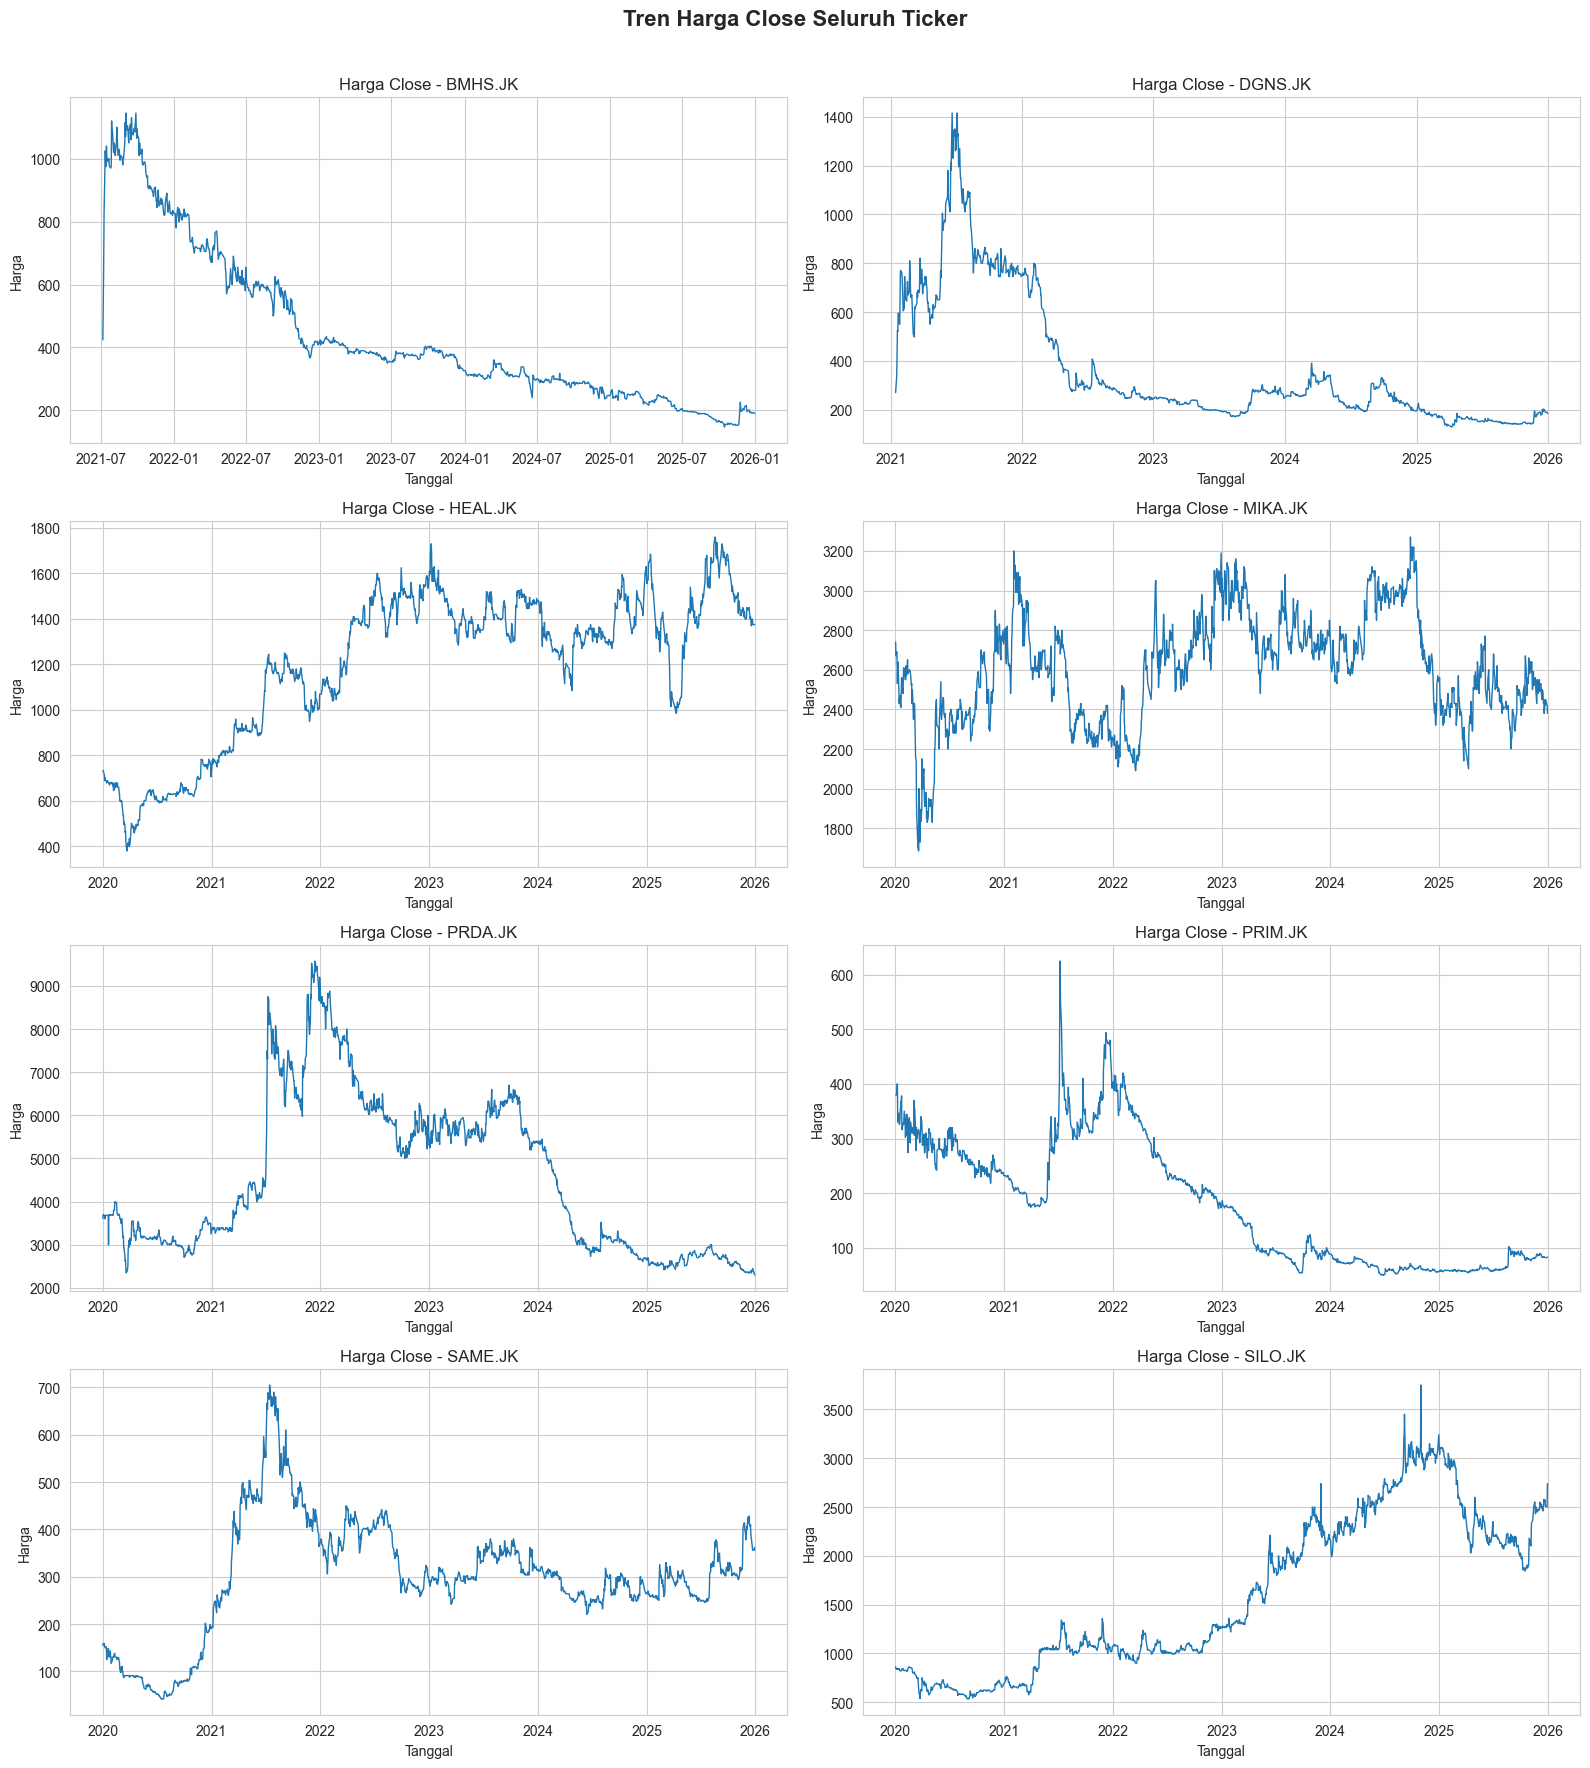

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for ax, (ticker, df) in zip(axes, raw_data.items()):
    ax.plot(df.index, df['Close'], linewidth=1)
    ax.set_title(f"Harga Close - {ticker}")
    ax.set_xlabel("Tanggal")
    ax.set_ylabel("Harga")

plt.suptitle("Tren Harga Close Seluruh Ticker", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_price_trend.png", dpi=300)
plt.show()


### 5.4 Distribusi Return Harian

Histogram + KDE dari return harian tiap saham untuk melihat volatilitas dan bentuk sebaran (normal/skewed/fat-tail).


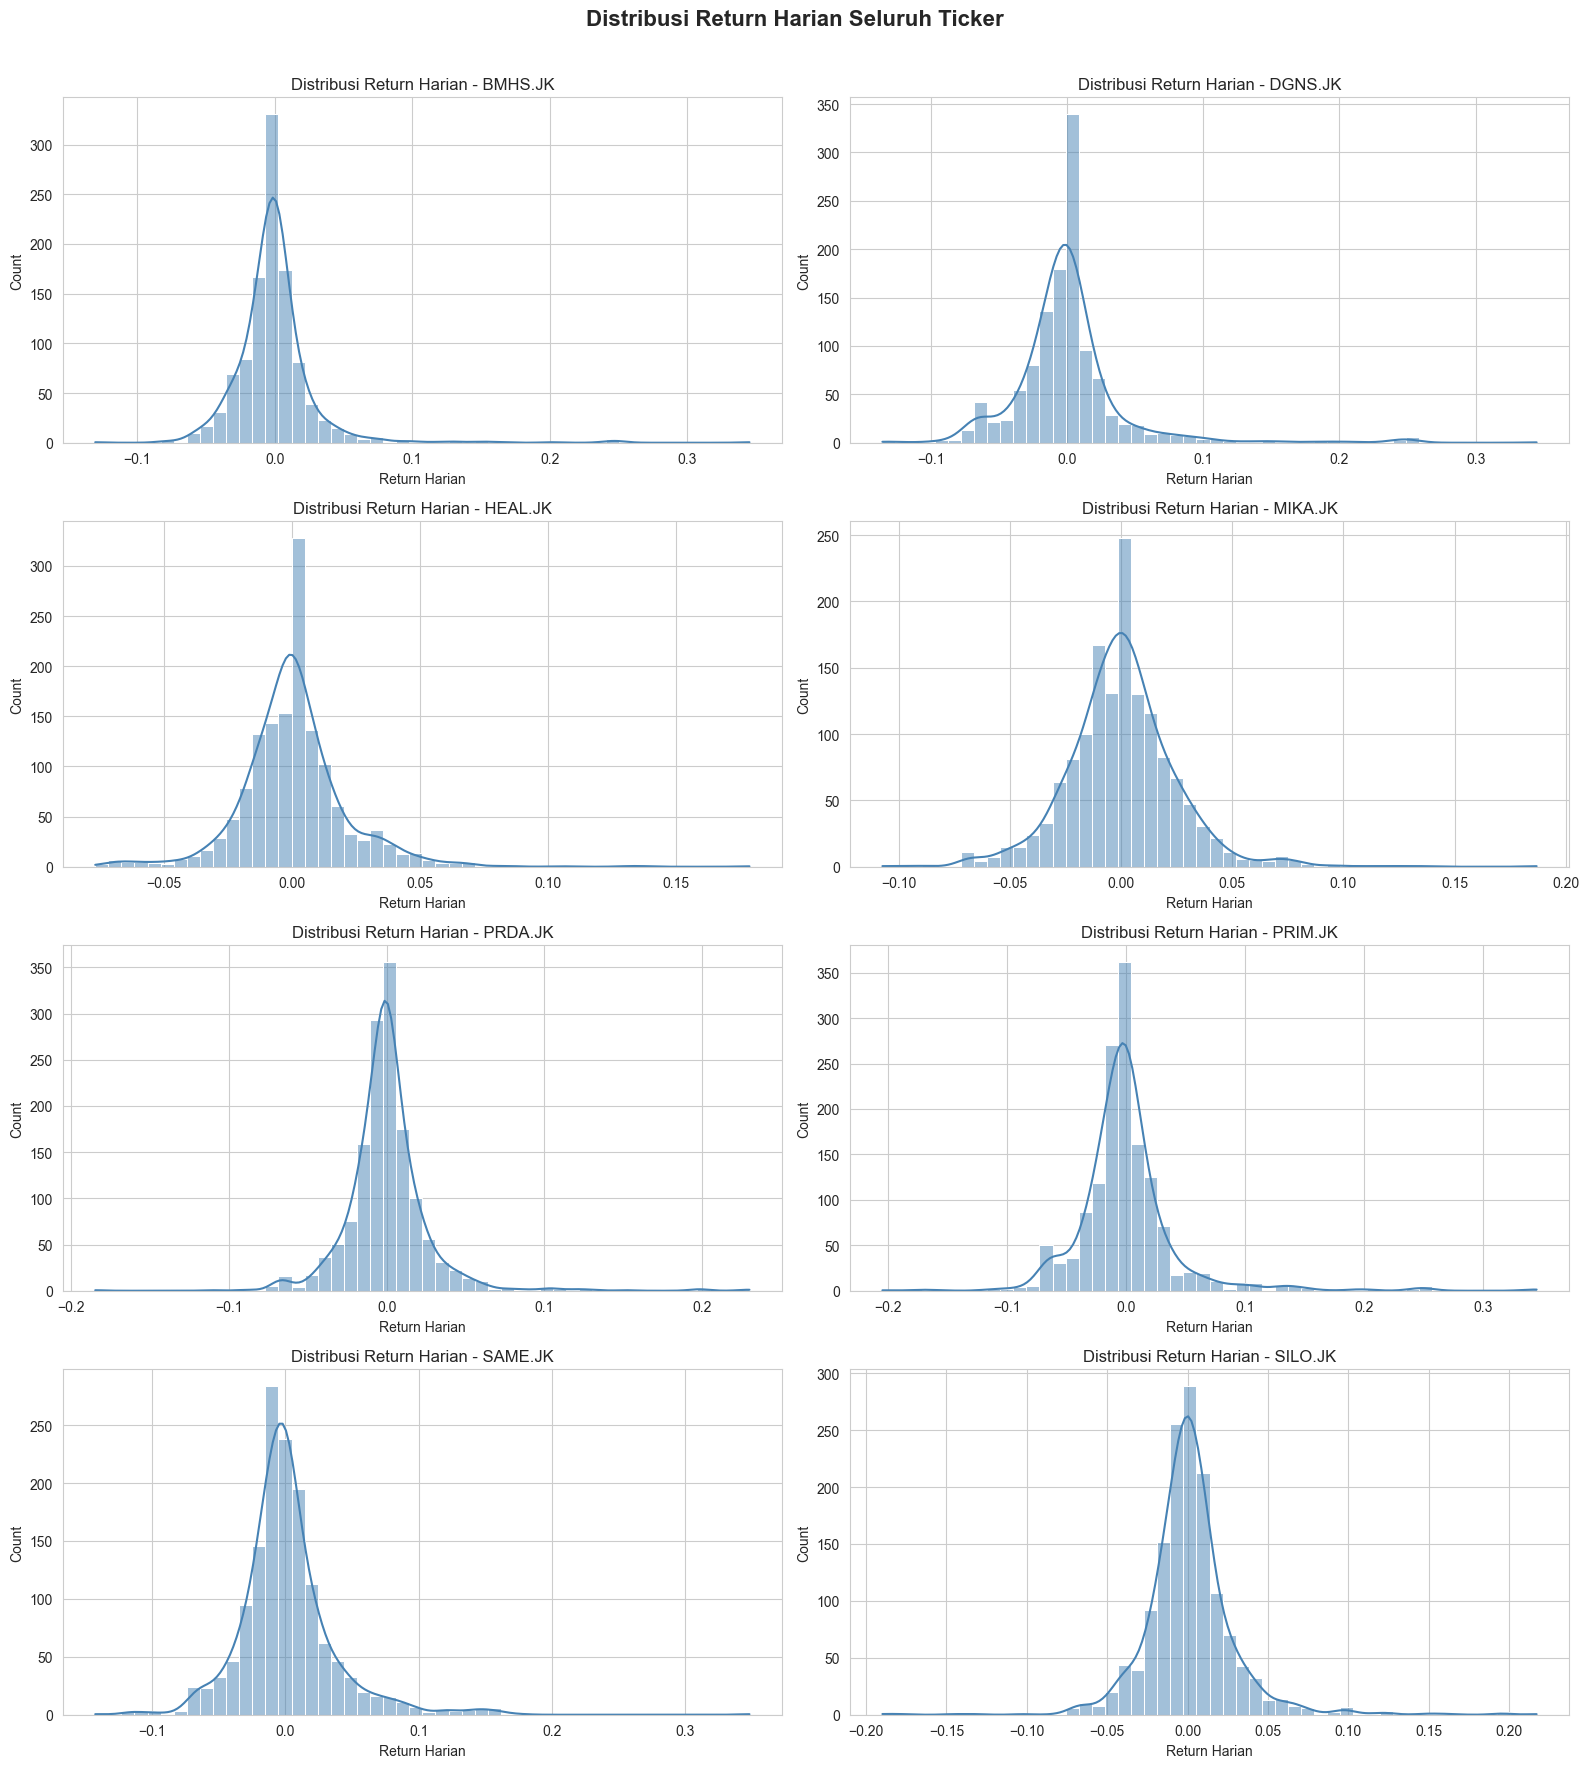

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for ax, (ticker, df) in zip(axes, raw_data.items()):
    daily_return = df['Close'].pct_change().dropna()
    sns.histplot(daily_return, bins=50, kde=True, ax=ax, color='steelblue')
    ax.set_title(f"Distribusi Return Harian - {ticker}")
    ax.set_xlabel("Return Harian")

plt.suptitle("Distribusi Return Harian Seluruh Ticker", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_return_distribution.png", dpi=300)
plt.show()


### 5.5 Korelasi Harga Antar Saham

Heatmap korelasi harga Close antar ticker. Berguna untuk melihat apakah saham-saham ini bergerak searah
(misalnya karena satu sektor yang sama) yang berimplikasi pada diversifikasi jika dipakai bersamaan dalam portofolio.


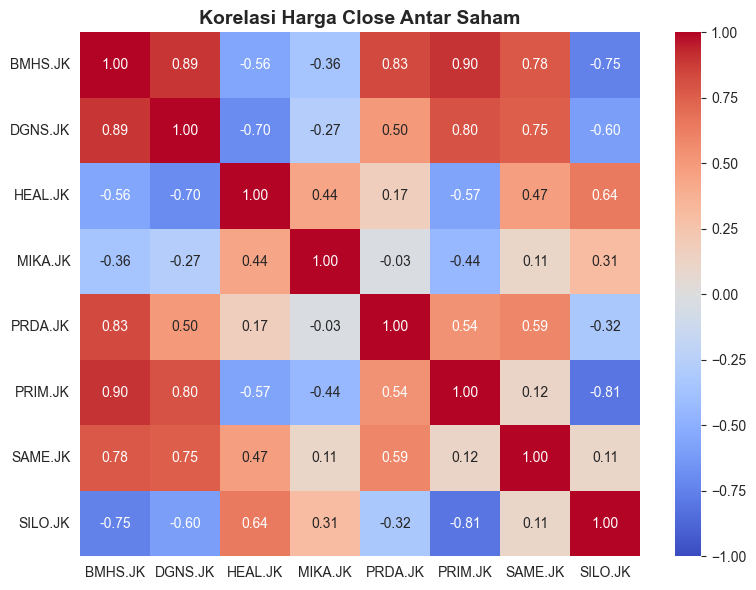

In [9]:
close_prices = pd.DataFrame({
    ticker: df['Close'] for ticker, df in raw_data.items()
})

corr_matrix = close_prices.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi Harga Close Antar Saham", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=300)
plt.show()


## 6. Fungsi Feature Engineering & Labeling

Dibuat dalam bentuk fungsi (`add_features` dan `add_label`) agar bisa dipanggil ulang secara konsisten,
baik saat EDA fitur maupun saat proses modeling per ticker, tanpa duplikasi kode.

Fitur yang dihitung:
- `rsi`: Relative Strength Index (14 hari)
- `tema_20_rel`: posisi harga relatif terhadap TEMA 20 hari
- `bb_width`: lebar Bollinger Band (20, 2 std) relatif terhadap middle band
- `volume_rel`: volume hari ini relatif terhadap rata-rata volume 20 hari
- `momentum_5`: return 5 hari terakhir

Label dibuat dari return `lookup_periode` hari ke depan dibandingkan `threshold`:
- `1` (Buy) jika return masa depan > threshold
- `-1` (Sell) jika return masa depan < -threshold
- `0` (Hold) selain itu


In [10]:
def add_features(df):
    df = df.copy()

    df['rsi'] = ta.rsi(df['Close'], length=14)

    df['tema_20_rel'] = (
        df['Close'] / ta.tema(df['Close'], length=20)
    ) - 1

    bb = ta.bbands(df['Close'], length=20, std=2)
    df['bb_upper'] = bb['BBU_20_2.0']
    df['bb_middle'] = bb['BBM_20_2.0']
    df['bb_lower'] = bb['BBL_20_2.0']

    df['bb_width'] = (
        (df['bb_upper'] - df['bb_lower']) / df['bb_middle']
    )

    df['volume_rel'] = (
        df['Volume'] / df['Volume'].rolling(20).mean()
    )

    df['momentum_5'] = (
        df['Close'] / df['Close'].shift(5)
    ) - 1

    return df


def add_label(df, lookup_periode, threshold):
    df = df.copy()

    df["Future_Return"] = (
        df["Close"].shift(-lookup_periode) / df["Close"]
    ) - 1

    df["Label"] = 0
    df.loc[df["Future_Return"] > threshold, "Label"] = 1
    df.loc[df["Future_Return"] < -threshold, "Label"] = -1

    df = df.drop(columns=['Adj Close', 'Future_Return'], errors='ignore')
    df = df.dropna()

    return df


## 7. Terapkan Feature Engineering & Labeling ke Semua Ticker

Hasilnya disimpan di `processed_data` (dictionary per ticker) agar dipakai bersama oleh EDA fitur/label
maupun tahap modeling, tanpa menghitung ulang.


In [11]:
processed_data = {}

for ticker, df in raw_data.items():
    df_feat = add_features(df)
    df_feat = add_label(df_feat, lookup_periode, threshold)
    processed_data[ticker] = df_feat

print("Contoh data setelah feature engineering & labeling:")
processed_data[tickers_list[0]].tail()


Contoh data setelah feature engineering & labeling:


,Close,High,Low,Open,Volume,rsi,tema_20_rel,bb_upper,bb_middle,bb_lower,bb_width,volume_rel,momentum_5,Label
Date,,,,,,,,,,,,,,
2025-12-22,192.0,197.0,183.0,194.0,7018900,50.128087,-0.045380,215.285066,201.90,188.514934,0.132591,0.282392,-0.040000,0
2025-12-23,193.0,195.0,189.0,192.0,5599600,50.950765,-0.031576,214.762862,201.15,187.537138,0.135350,0.324431,-0.044554,0
2025-12-24,192.0,195.0,188.0,193.0,5125100,50.061437,-0.027798,214.984034,200.90,186.815966,0.140209,0.336840,-0.040000,0
2025-12-29,192.0,195.0,189.0,192.0,3299800,50.061437,-0.020335,215.172741,200.65,186.127259,0.144757,0.259069,-0.005181,0
2025-12-30,190.0,192.0,189.0,192.0,4969400,48.113489,-0.021717,215.466767,200.25,185.033233,0.151978,0.400319,-0.020619,0


## 8. EDA Fitur & Label

Setelah fitur dan label terbentuk, kita cek lagi sebarannya sebelum masuk ke modeling:
- Apakah label seimbang antar kelas (Buy/Hold/Sell)?
- Bagaimana bentuk distribusi tiap fitur di seluruh ticker?


### 8.1 Distribusi Label per Ticker

Melihat proporsi Sell/Hold/Buy di tiap saham. Distribusi yang timpang (misalnya Hold mendominasi)
adalah hal wajar untuk labeling berbasis threshold return, tapi penting diketahui karena
memengaruhi interpretasi hasil model nantinya (makanya `class_weight="balanced"` dipakai saat training).


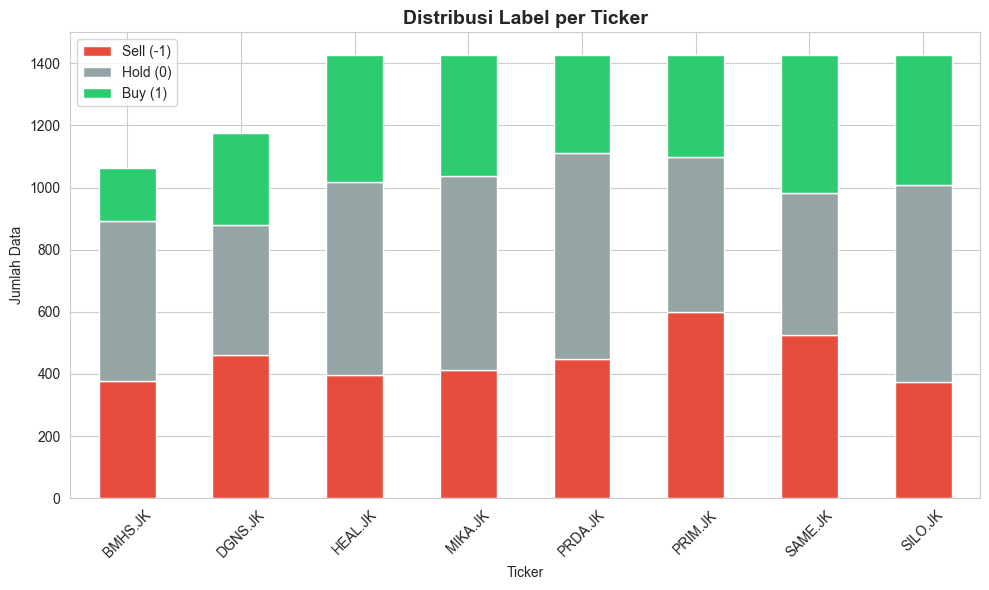

,Sell (-1),Hold (0),Buy (1)
Ticker,,,
BMHS.JK,378,514,171
DGNS.JK,461,419,297
HEAL.JK,396,621,411
MIKA.JK,413,625,390
PRDA.JK,448,662,318
PRIM.JK,601,496,331
SAME.JK,526,456,446
SILO.JK,374,633,421


In [12]:
label_counts = []

for ticker, df in processed_data.items():
    counts = df['Label'].value_counts().reindex([-1, 0, 1], fill_value=0)
    label_counts.append({
        "Ticker": ticker,
        "Sell (-1)": counts[-1],
        "Hold (0)": counts[0],
        "Buy (1)": counts[1]
    })

label_counts_df = pd.DataFrame(label_counts).set_index("Ticker")

label_counts_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#e74c3c', '#95a5a6', '#2ecc71']
)
plt.title("Distribusi Label per Ticker", fontsize=14, fontweight='bold')
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eda_label_distribution.png", dpi=300)
plt.show()

label_counts_df


### 8.2 Distribusi Tiap Fitur (Seluruh Ticker)

KDE plot untuk membandingkan bentuk sebaran tiap fitur antar saham. Berguna untuk mendeteksi
outlier ekstrem atau fitur yang skalanya sangat berbeda antar ticker.


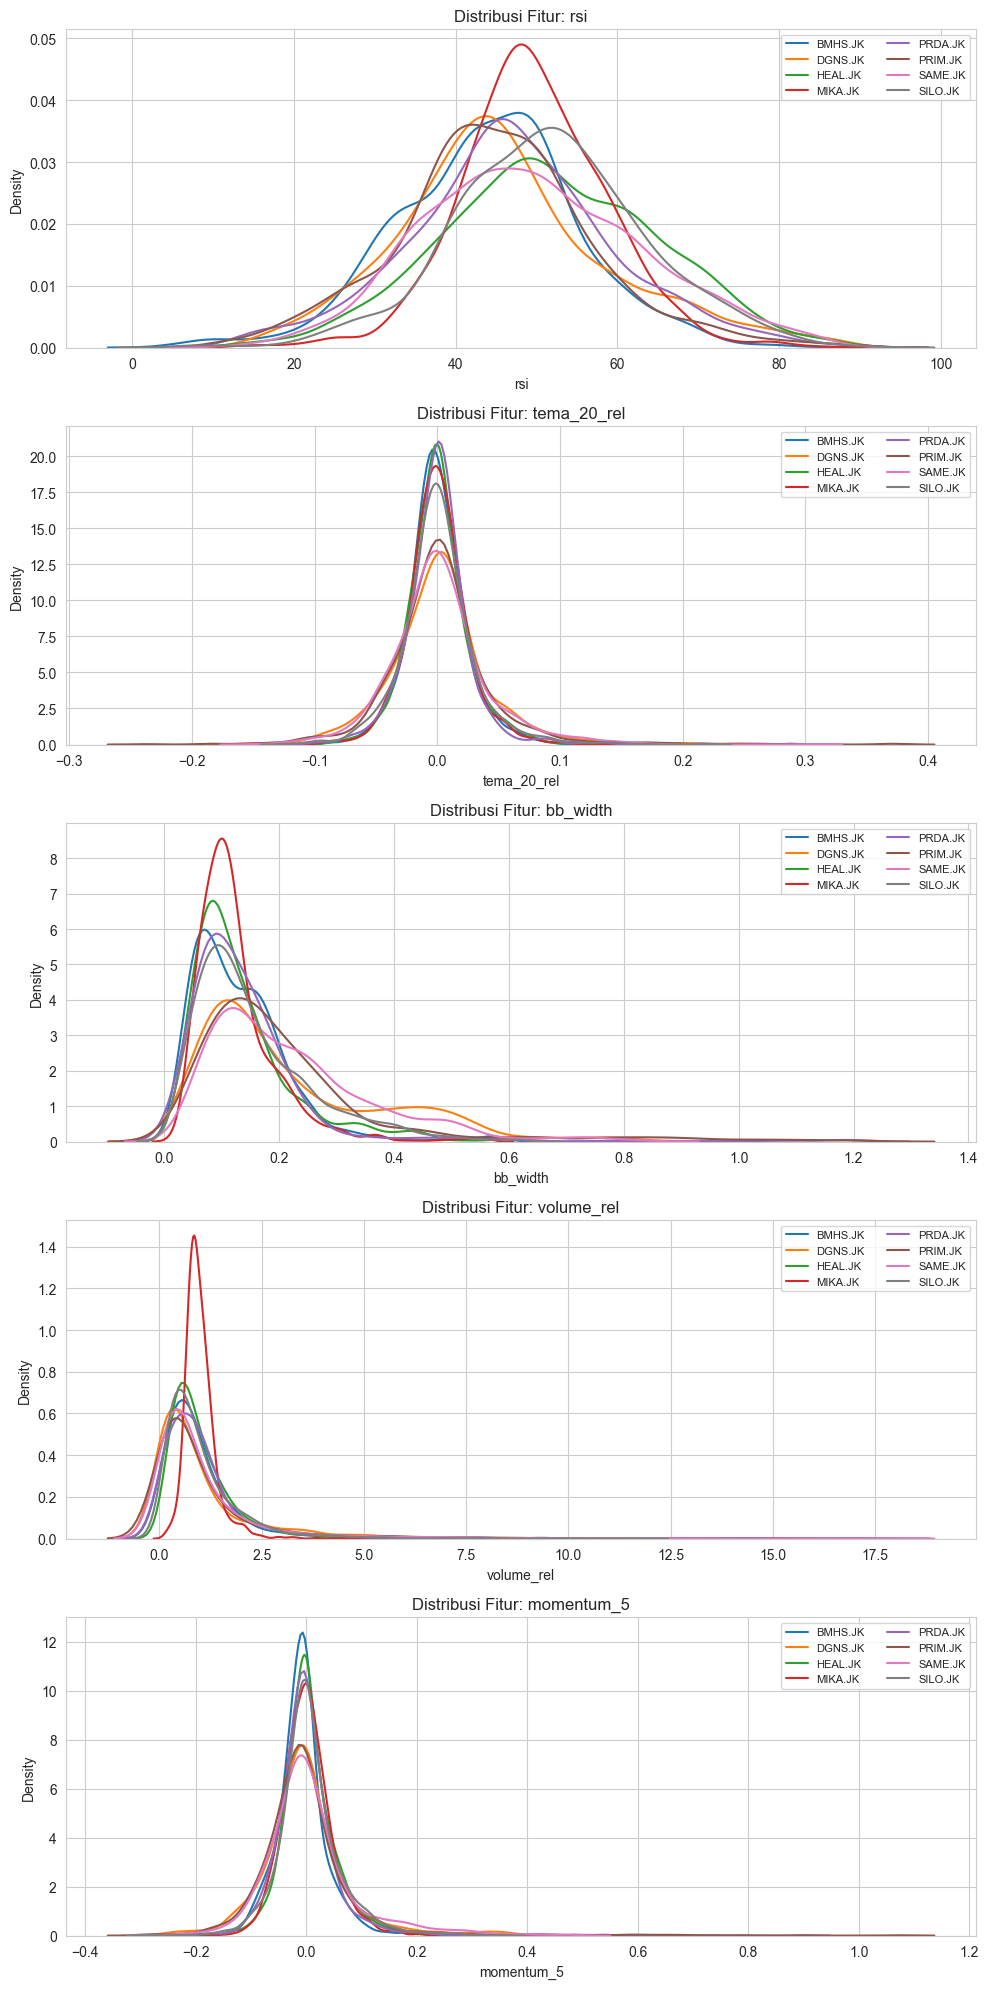

In [13]:
fig, axes = plt.subplots(len(features), 1, figsize=(10, 4 * len(features)))

for ax, feat in zip(axes, features):
    for ticker, df in processed_data.items():
        sns.kdeplot(df[feat], ax=ax, label=ticker)
    ax.set_title(f"Distribusi Fitur: {feat}")
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig("eda_feature_distribution.png", dpi=300)
plt.show()


## 9. Modeling & Backtesting per Ticker

Untuk tiap ticker:
1. Split data menjadi Train (60%), Test (20%), Forward/Backtest (20%) secara berurutan (time-based split, bukan random).
2. Latih `RandomForestClassifier` dengan parameter hasil tuning (`rf_params_map`).
3. Evaluasi di data Test dan data Forward menggunakan accuracy, classification report, dan confusion matrix.
4. Jalankan backtest strategi trading berbasis sinyal model pada periode Forward menggunakan library `backtesting`.
5. Simpan hasil ringkasan performa ke `results`.


In [14]:
for ticker in tickers_list:

    if ticker not in processed_data:
        continue

    print(f"\n========================")
    print(f"PROCESSING {ticker}")
    print(f"========================")

    df = processed_data[ticker]

    X = df[features]
    Y = df['Label']

    total_len = len(df)
    train_idx = int(total_len * 0.60)
    test_idx = int(total_len * 0.80)

    X_train = X.iloc[:train_idx]
    Y_train = Y.iloc[:train_idx]

    X_test = X.iloc[train_idx:test_idx]
    Y_test = Y.iloc[train_idx:test_idx]

    X_forward = X.iloc[test_idx:]
    Y_forward = Y.iloc[test_idx:]

    df_forward = df.iloc[test_idx:].copy()

    print(f"Train   : {len(X_train)}")
    print(f"Test    : {len(X_test)}")
    print(f"Forward : {len(X_forward)}")

    # =====================
    # MODEL
    # =====================
    params = rf_params_map[ticker]

    rf_model = RandomForestClassifier(
        **params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        max_features='sqrt'
    )

    rf_model.fit(X_train, Y_train)

    # =====================
    # PREDICTION
    # =====================
    Y_train_pred = rf_model.predict(X_train)
    Y_test_pred = rf_model.predict(X_test)
    Y_fwd_pred = rf_model.predict(X_forward)

    # =====================
    # CONFUSION MATRIX
    # =====================
    cm_test = confusion_matrix(Y_test, Y_test_pred, labels=[-1, 0, 1])
    cm_backtest = confusion_matrix(Y_forward, Y_fwd_pred, labels=[-1, 0, 1])

    testing_cms.append((ticker, cm_test))
    backtesting_cms.append((ticker, cm_backtest))

    # =====================
    # EVALUATION
    # =====================
    print(f"Test Accuracy     : {accuracy_score(Y_test, Y_test_pred):.4f}")
    print(f"Backtest Accuracy : {accuracy_score(Y_forward, Y_fwd_pred):.4f}")

    print("\nClassification Report (Test):")
    print(classification_report(Y_test, Y_test_pred))

    print("\nClassification Report (Backtest):")
    print(classification_report(Y_forward, Y_fwd_pred))

    # =====================
    # STRATEGY
    # =====================
    class RFStrategy(Strategy):

        def init(self):
            self.model = rf_model
            self.features = features

        def next(self):
            X_today = self.data.df.iloc[[-1]][self.features]
            signal = self.model.predict(X_today)[0]

            if signal == 1:
                if not self.position.is_long:
                    self.buy()
            elif signal == -1:
                if self.position.is_long:
                    self.position.close()

    # =====================
    # BACKTEST
    # =====================
    bt = Backtest(
        df_forward,
        RFStrategy,
        cash=100_000_000,
        commission=0.002,
        exclusive_orders=True,
        margin=1.0
    )

    stats = bt.run()

    print("\n=== BACKTEST RESULT ===")
    print(stats)

    # =====================
    # SAVE RESULT
    # =====================
    results.append({
        "Ticker": ticker,
        "Buy Hold Return (%)": stats["Buy & Hold Return [%]"],
        "Return (%)": stats["Return [%]"],
        "Sharpe Ratio": stats["Sharpe Ratio"],
        "Win Rate (%)": stats["Win Rate [%]"],
        "Max Drawdown (%)": stats["Max. Drawdown [%]"],
        "Jumlah Trade": stats["# Trades"],
    })



PROCESSING BMHS.JK
Train   : 637
Test    : 213
Forward : 213
Test Accuracy     : 0.4178
Backtest Accuracy : 0.4601

Classification Report (Test):
              precision    recall  f1-score   support

          -1       0.41      0.62      0.49        74
           0       0.45      0.34      0.39       101
           1       0.36      0.24      0.29        38

    accuracy                           0.42       213
   macro avg       0.41      0.40      0.39       213
weighted avg       0.42      0.42      0.41       213


Classification Report (Backtest):
              precision    recall  f1-score   support

          -1       0.34      0.29      0.32        75
           0       0.58      0.71      0.63       102
           1       0.17      0.11      0.13        36

    accuracy                           0.46       213
   macro avg       0.36      0.37      0.36       213
weighted avg       0.43      0.46      0.44       213



Backtest.run:   0%|          | 0/212 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2025-02-07 00:00:00
End                       2025-12-30 00:00:00
Duration                    326 days 00:00:00
Exposure Time [%]                    30.98592
Equity Final [$]                  77094079.06
Equity Peak [$]                   100000000.0
Commissions [$]                    2781934.94
Return [%]                          -22.90592
Buy & Hold Return [%]               -20.16807
Return (Ann.) [%]                   -26.49198
Volatility (Ann.) [%]                12.30502
CAGR [%]                            -18.21634
Sharpe Ratio                         -2.15294
Sortino Ratio                        -1.98803
Calmar Ratio                         -0.93431
Alpha [%]                           -20.01835
Beta                                  0.14318
Max. Drawdown [%]                   -28.35455
Avg. Drawdown [%]                   -28.35455
Max. Drawdown Duration      287 days 00:00:00
Avg. Drawdown Duration      287 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/235 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2025-01-02 00:00:00
End                       2025-12-30 00:00:00
Duration                    362 days 00:00:00
Exposure Time [%]                    37.28814
Equity Final [$]                101211422.118
Equity Peak [$]                 115888933.946
Commissions [$]                   5435400.882
Return [%]                            1.21142
Buy & Hold Return [%]                -6.59898
Return (Ann.) [%]                     1.29408
Volatility (Ann.) [%]                42.87986
CAGR [%]                              0.84177
Sharpe Ratio                          0.03018
Sortino Ratio                         0.05848
Calmar Ratio                          0.04461
Alpha [%]                              3.8993
Beta                                  0.40732
Max. Drawdown [%]                   -29.00988
Avg. Drawdown [%]                   -22.28143
Max. Drawdown Duration      249 days 00:00:00
Avg. Drawdown Duration      178 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                    63.28671
Equity Final [$]                   84026212.6
Equity Peak [$]                  115984575.81
Commissions [$]                    10969397.4
Return [%]                          -15.97379
Buy & Hold Return [%]               -11.29032
Return (Ann.) [%]                   -14.21716
Volatility (Ann.) [%]                23.52224
CAGR [%]                             -9.50769
Sharpe Ratio                         -0.60441
Sortino Ratio                        -0.74201
Calmar Ratio                         -0.50965
Alpha [%]                           -10.31519
Beta                                  0.50119
Max. Drawdown [%]                   -27.89599
Avg. Drawdown [%]                   -10.20472
Max. Drawdown Duration      309 days 00:00:00
Avg. Drawdown Duration       83 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                    65.73427
Equity Final [$]                 130084779.52
Equity Peak [$]                  135402839.04
Commissions [$]                    7599300.02
Return [%]                           30.08478
Buy & Hold Return [%]               -22.97735
Return (Ann.) [%]                    26.08026
Volatility (Ann.) [%]                36.50573
CAGR [%]                              16.2973
Sharpe Ratio                          0.71442
Sortino Ratio                         1.44556
Calmar Ratio                          1.34359
Alpha [%]                            43.14603
Beta                                  0.56844
Max. Drawdown [%]                   -19.41085
Avg. Drawdown [%]                     -4.1473
Max. Drawdown Duration      188 days 00:00:00
Avg. Drawdown Duration       25 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                      4.1958
Equity Final [$]                  96570156.54
Equity Peak [$]                   100000000.0
Commissions [$]                    1560853.46
Return [%]                           -3.42984
Buy & Hold Return [%]               -24.59016
Return (Ann.) [%]                    -3.02834
Volatility (Ann.) [%]                 2.99309
CAGR [%]                             -1.98346
Sharpe Ratio                         -1.01178
Sortino Ratio                        -1.14216
Calmar Ratio                         -0.56002
Alpha [%]                            -2.75875
Beta                                  0.02729
Max. Drawdown [%]                    -5.40757
Avg. Drawdown [%]                    -5.40757
Max. Drawdown Duration      258 days 00:00:00
Avg. Drawdown Duration      258 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                    43.00699
Equity Final [$]                116932427.042
Equity Peak [$]                 135281096.642
Commissions [$]                   6788588.822
Return [%]                           16.93243
Buy & Hold Return [%]                33.87097
Return (Ann.) [%]                    14.77803
Volatility (Ann.) [%]                53.48811
CAGR [%]                              9.39484
Sharpe Ratio                          0.27629
Sortino Ratio                          0.7645
Calmar Ratio                          0.51654
Alpha [%]                            -5.88213
Beta                                  0.67357
Max. Drawdown [%]                   -28.60978
Avg. Drawdown [%]                   -22.45683
Max. Drawdown Duration      301 days 00:00:00
Avg. Drawdown Duration      210 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                    43.35664
Equity Final [$]                163470125.772
Equity Peak [$]                 196925280.532
Commissions [$]                   7401184.228
Return [%]                           63.47013
Buy & Hold Return [%]                27.46479
Return (Ann.) [%]                    54.19298
Volatility (Ann.) [%]                67.11505
CAGR [%]                             32.59295
Sharpe Ratio                          0.80746
Sortino Ratio                         2.48056
Calmar Ratio                          2.59808
Alpha [%]                            45.68725
Beta                                  0.64748
Max. Drawdown [%]                   -20.85886
Avg. Drawdown [%]                    -9.90315
Max. Drawdown Duration      168 days 00:00:00
Avg. Drawdown Duration       47 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                    48.25175
Equity Final [$]                 132677891.74
Equity Peak [$]                  132677891.74
Commissions [$]                    6438307.34
Return [%]                           32.67789
Buy & Hold Return [%]               -12.17949
Return (Ann.) [%]                    28.29216
Volatility (Ann.) [%]                 41.2888
CAGR [%]                             17.62247
Sharpe Ratio                          0.68523
Sortino Ratio                         1.41239
Calmar Ratio                          1.18069
Alpha [%]                            38.76523
Beta                                   0.4998
Max. Drawdown [%]                    -23.9623
Avg. Drawdown [%]                    -5.59173
Max. Drawdown Duration      279 days 00:00:00
Avg. Drawdown Duration       53 days 00:00:00
# Trades 

## 10. Visualisasi Confusion Matrix

Fungsi untuk menampilkan 4 confusion matrix sekaligus dalam satu gambar (grid 2x2), dipakai untuk
membandingkan performa Testing dan Backtesting antar kelompok ticker.


In [15]:
def plot_group_confusion_matrix(cm_list, title, filename):

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for ax, (ticker, cm) in zip(axes, cm_list):
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            ax=ax
        )
        ax.set_title(ticker, fontsize=12)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.suptitle(title, fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(filename, dpi=300)
    plt.show()


### 10.1 Confusion Matrix - Testing (Ticker 1-4 dan 5-8)


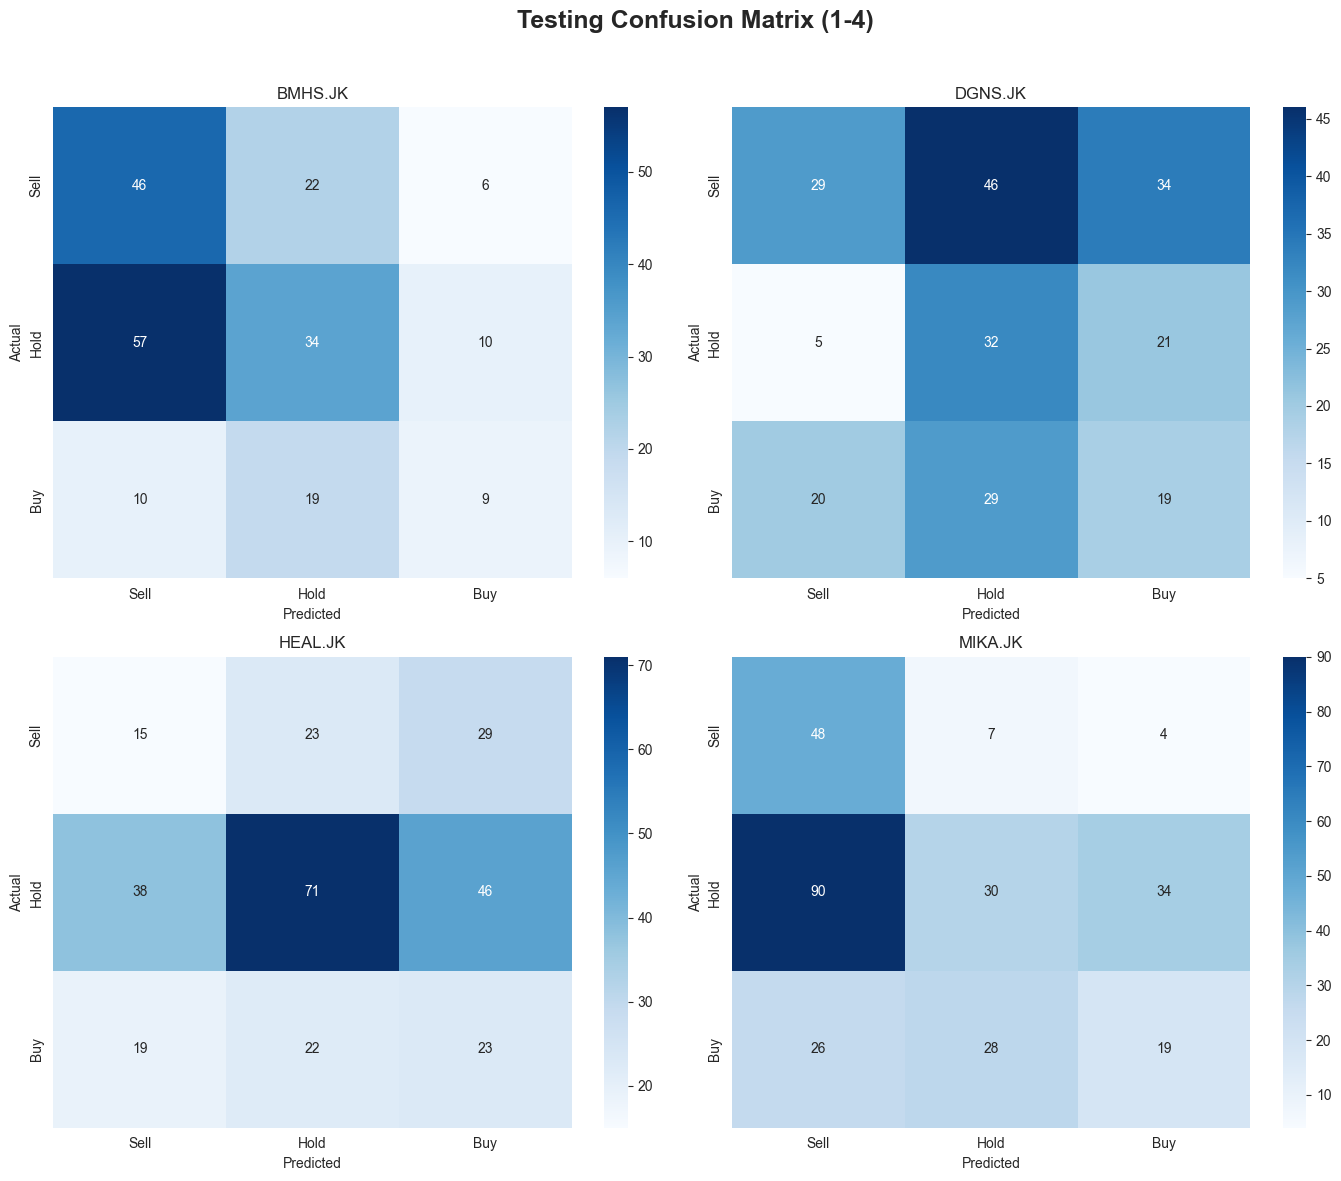

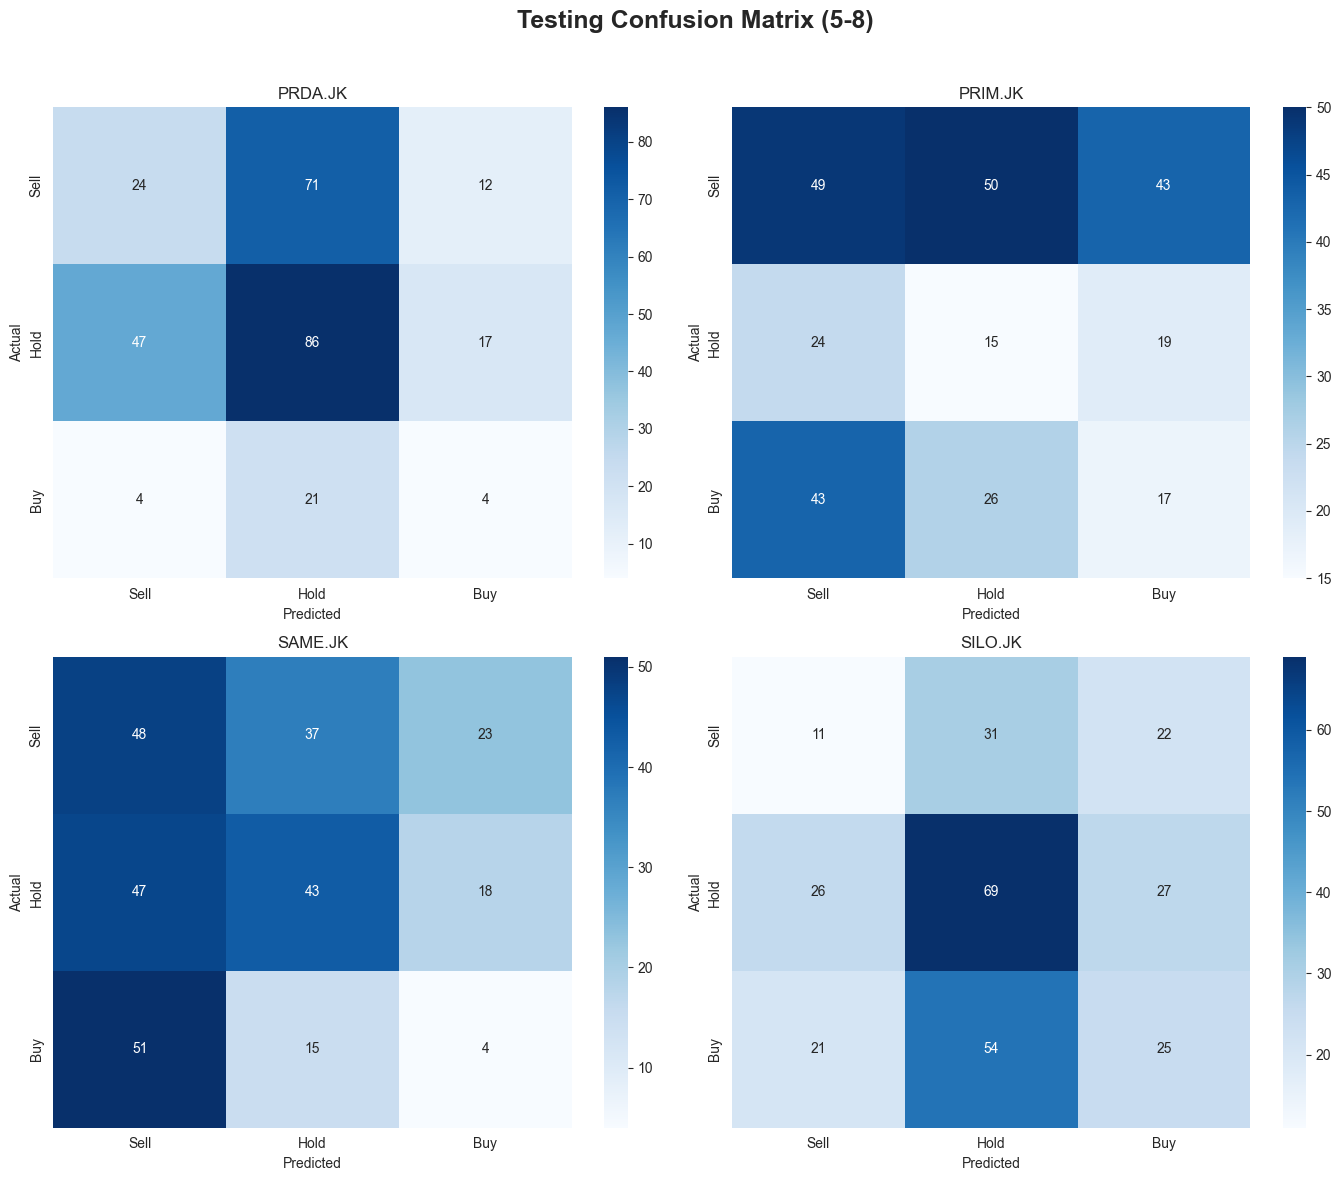

In [16]:
plot_group_confusion_matrix(
    testing_cms[:4],
    "Testing Confusion Matrix (1-4)",
    "testing_confusion_matrix_1.png"
)

plot_group_confusion_matrix(
    testing_cms[4:8],
    "Testing Confusion Matrix (5-8)",
    "testing_confusion_matrix_2.png"
)


### 10.2 Confusion Matrix - Backtesting (Ticker 1-4 dan 5-8)


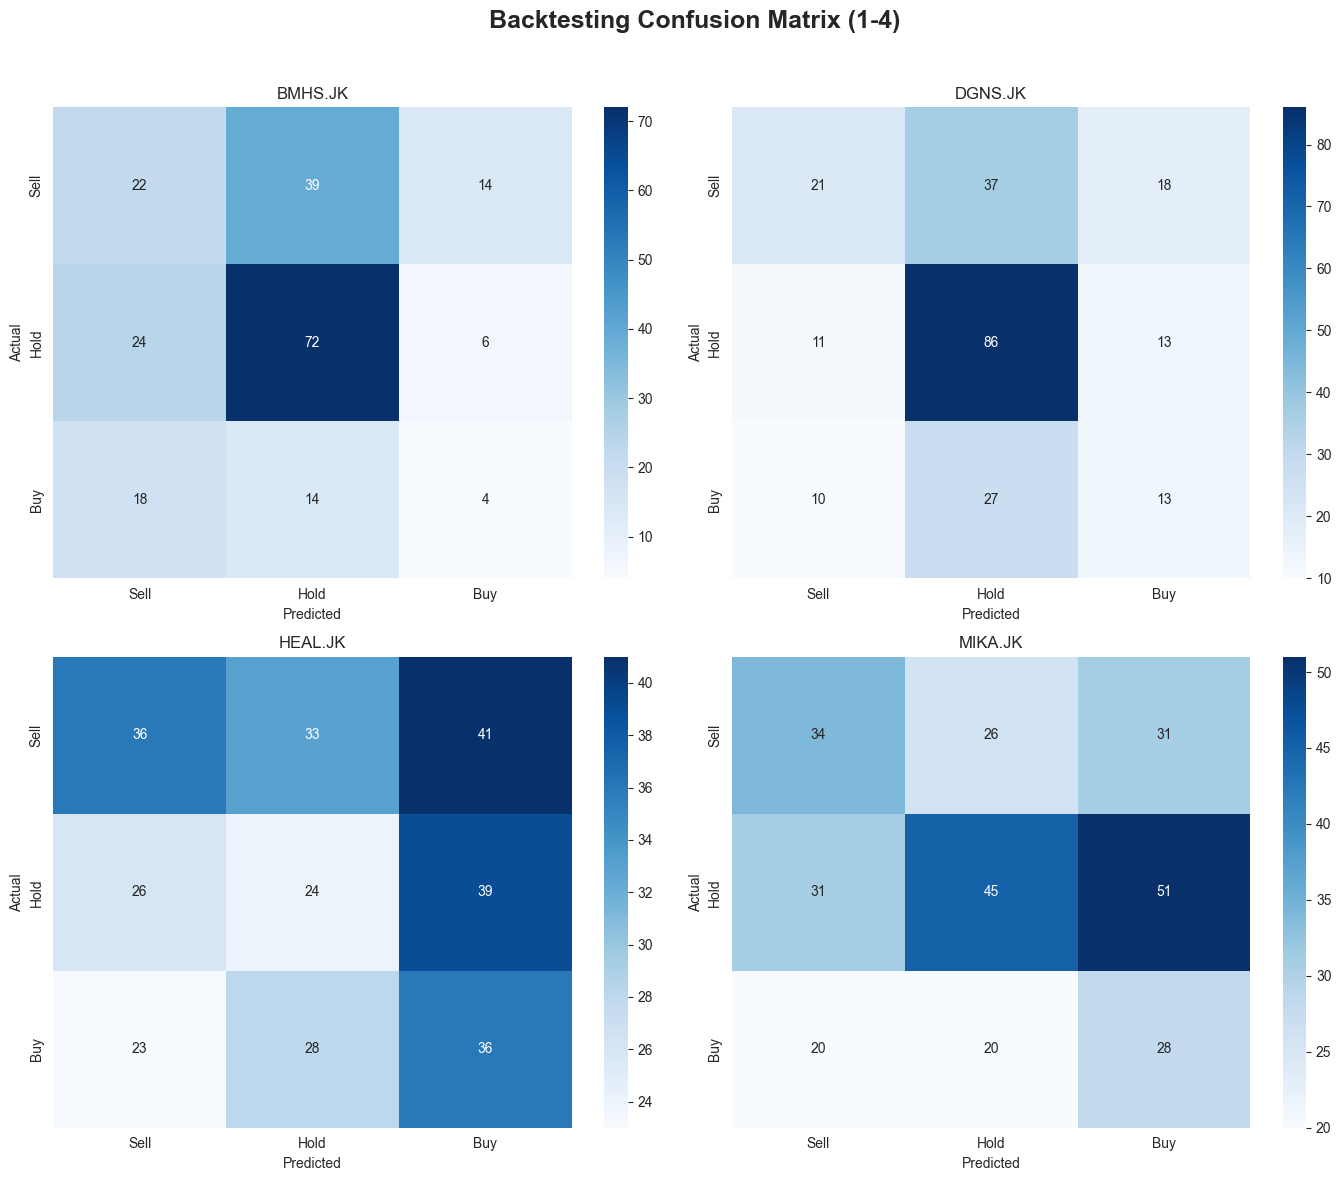

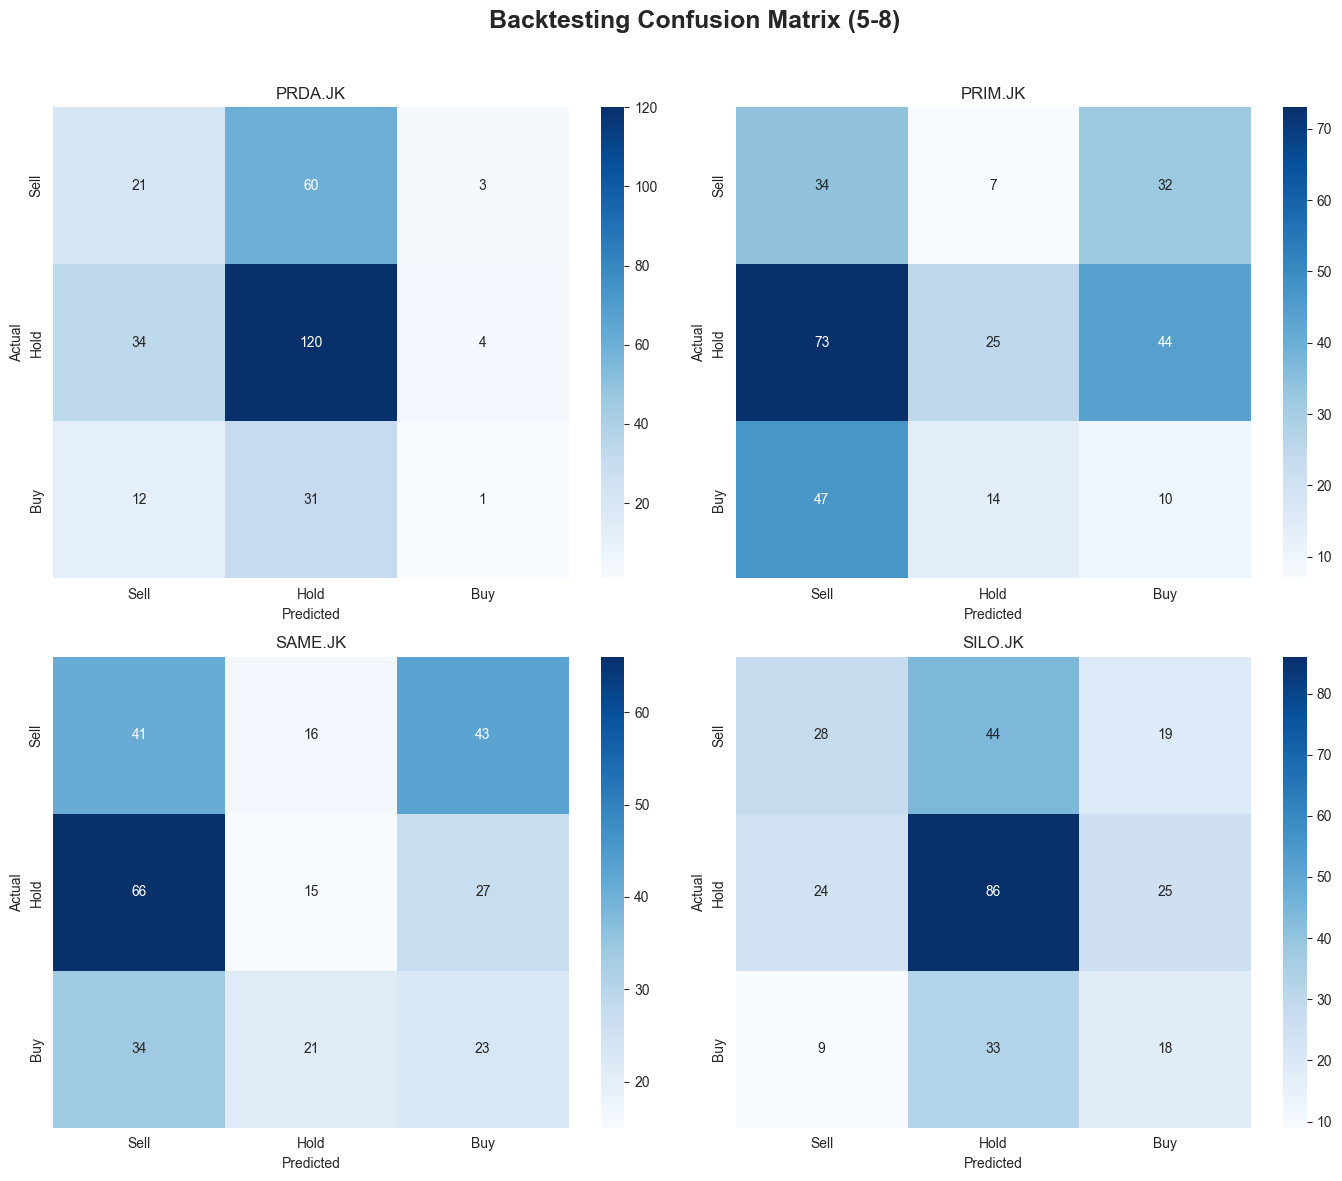

In [17]:
plot_group_confusion_matrix(
    backtesting_cms[:4],
    "Backtesting Confusion Matrix (1-4)",
    "backtesting_confusion_matrix_1.png"
)

plot_group_confusion_matrix(
    backtesting_cms[4:8],
    "Backtesting Confusion Matrix (5-8)",
    "backtesting_confusion_matrix_2.png"
)


## 11. Ringkasan Hasil Backtest Seluruh Ticker

Menampilkan tabel ringkasan performa (Return, Buy & Hold Return, Sharpe Ratio, Win Rate, Max Drawdown,
Jumlah Trade) untuk seluruh ticker dalam satu tabel agar mudah dibandingkan.


In [18]:
results_df = pd.DataFrame(results)

print("==============================")
print("=== HASIL BACKTEST SEMUA TICKER ===")
print("==============================")

results_df


=== HASIL BACKTEST SEMUA TICKER ===


,Ticker,Buy Hold Return (%),Return (%),Sharpe Ratio,Win Rate (%),Max Drawdown (%),Jumlah Trade
0,BMHS.JK,-20.168067,-22.905921,-2.152941,37.500000,-28.354550,8
1,DGNS.JK,-6.598985,1.211422,0.030179,28.571429,-29.009885,14
2,HEAL.JK,-11.290323,-15.973787,-0.604413,59.259259,-27.895987,27
3,MIKA.JK,-22.977346,30.084780,0.714416,76.470588,-19.410846,17
4,PRDA.JK,-24.590164,-3.429843,-1.011777,25.000000,-5.407565,4
5,PRIM.JK,33.870968,16.932427,0.276286,37.500000,-28.609777,16
6,SAME.JK,27.464789,63.470126,0.807464,71.428571,-20.858863,14
7,SILO.JK,-12.179487,32.677892,0.685226,58.823529,-23.962299,17
